# CircuitVQA — Questions-réponses sur schémas électroniques

**Objectif** : à partir de l'image d'un schéma, répondre en langage naturel à des questions sur le circuit.

---

## Architecture retenue : pipeline hybride + graphe + LLM outillé

```
IMAGE ──▶ ① détection ──▶ ② identifiants ──▶ ③ traçage fils ──▶ ④ OCR ──▶ ⑤ GRAPHE ──▶ ⑥ LLM
```

| # | Étape | Rôle | Technologie |
|---|---|---|---|
| ① | Détection | localiser les composants | YOLO11 (entraîné sur données générées) |
| ② | Identifiants | nommer R1, C1… | numérotation par position de lecture |
| ③ | Traçage des fils | reconstruire les connexions | composantes connexes + union-find |
| ④ | OCR | lire références et valeurs | EasyOCR + corrections ciblées |
| ⑤ | **Graphe** | **représentation pivot** | pydantic (typé, validé) |
| ⑥ | LLM outillé | répondre en langage naturel | Qwen2.5 + appel d'outils |

### Le choix central : le LLM ne devine pas, il appelle un outil

Pour une question comme « combien de composants ? », deux approches étaient possibles :

- ❌ **donner la netlist au LLM et le laisser compter** — un petit modèle peut mal lire une liste de 20 lignes, sans aucune garantie
- ✅ **le LLM choisit l'outil `count_total_components`, on l'exécute sur le graphe, il reformule le résultat**

La réponse est alors **exacte par construction** (calculée, pas générée), et le LLM ne sert qu'à comprendre la question et formuler une phrase naturelle.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, 'Src')

import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx as nx
import pandas as pd

from Common.Config import HybridConfig
from Hybrid.Pipeline import HybridPipeline
from Graph.Builder import from_annotation
from Graph.Tools import build_tools
from Llm.Qwen_Client import QwenClient
from Llm.Tool_Agent import ToolAgent

cfg = HybridConfig.from_yaml('Configs/hybrid.yaml')
dataset_dir = cfg.resolve_path(cfg.data.dataset_dir)
WEIGHTS = 'Runs/hybrid/yolo11n_circuits/weights/best.pt'
print('Environnement chargé.')

Environnement chargé.


---
## 1. Le jeu de données : généré, donc annoté gratuitement

5000 schémas produits avec **schemdraw**, chacun accompagné de sa vérité terrain exacte (composants, positions, connexions, valeurs) — aucune annotation manuelle.

| Caractéristique | Valeur |
|---|---|
| Circuits | 4500 entraînement + 500 test |
| Templates | 48 (lycée → ingénieur), 2 domaines (électrique, logique) |
| Classes de composants | 22 |
| Contrôles qualité automatiques | 7 (fermeture, bboxes, terminaux, textes, jonctions, nets, lisibilité) |
| Taux de validité mesuré | 100 % sur 960 circuits vérifiés |

In [2]:
# choisir un circuit de démonstration — de préférence complexe
ann_files = sorted((dataset_dir / 'annotations' / 'test').glob('*.json'))

by_complexity = []
for f in ann_files:
    a = json.loads(f.read_text(encoding='utf-8'))
    by_complexity.append((len(a['components']), a.get('template', '?'), f))
by_complexity.sort(reverse=True)

print('Circuits les plus complexes du jeu de test :')
for n, tpl, f in by_complexity[:5]:
    print(f'  {n} composants — {tpl}')

# on prend un circuit avec une diode, pour illustrer la question de polarité
diode_circuits = [f for n, t, f in by_complexity
                  if any(k in t for k in ('zener', 'rectifier', 'led', 'bridge'))]
ann_path = diode_circuits[0] if diode_circuits else by_complexity[0][2]

ann = json.loads(ann_path.read_text(encoding='utf-8'))
image_path = dataset_dir / ann['image']
print(f"\nCircuit de démonstration : {ann.get('template')} ({len(ann['components'])} composants)")

Circuits les plus complexes du jeu de test :
  8 composants — multistage_amplifier
  8 composants — multistage_amplifier
  8 composants — multistage_amplifier
  7 composants — summing_amplifier
  7 composants — summing_amplifier

Circuit de démonstration : wheatstone_bridge (6 composants)


---
## 2. Étapes ① à ④ : de l'image aux composants identifiés

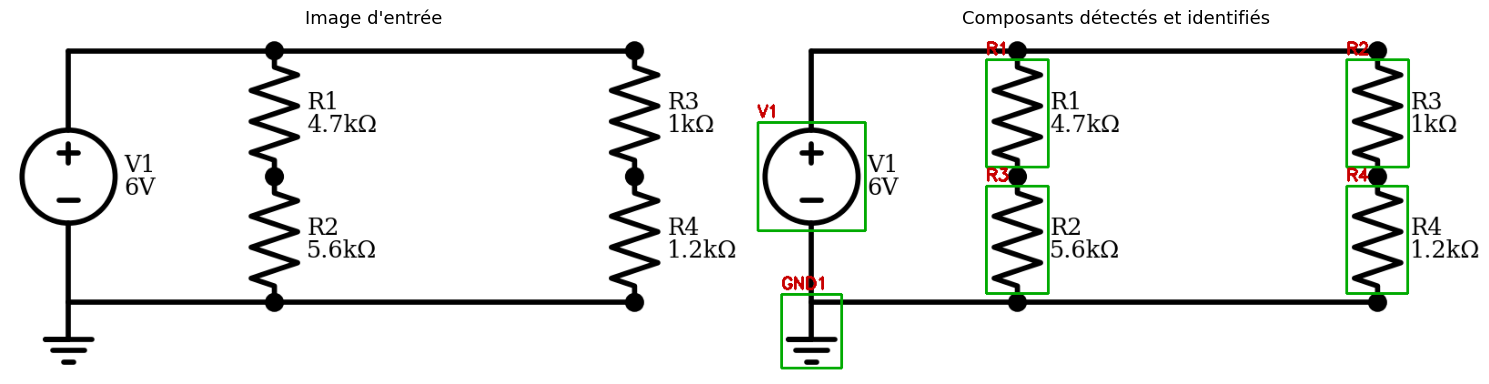

,id,classe,confiance,valeur lue (OCR)
0,R1,resistor,0.984,4.7kΩ
1,R2,resistor,0.985,1kΩ
2,V1,vsource,0.987,6V
3,R3,resistor,0.987,4.7kΩ
4,R4,resistor,0.987,1kΩ
5,GND1,ground,0.980,None


In [3]:
pipeline = HybridPipeline.from_config(cfg, weights=WEIGHTS)
result = pipeline.run(image_path)   # exécute ①②③④

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(mpimg.imread(image_path))
axes[0].set_title('Image d\'entrée', fontsize=13)
axes[0].axis('off')

img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
for c in result.components:
    x0, y0, x1, y1 = int(c.bbox.x0), int(c.bbox.y0), int(c.bbox.x1), int(c.bbox.y1)
    cv2.rectangle(img, (x0, y0), (x1, y1), (0, 170, 0), 2)
    cv2.putText(img, f'{c.id}', (x0, max(15, y0 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 0, 0), 2)
axes[1].imshow(img)
axes[1].set_title('Composants détectés et identifiés', fontsize=13)
axes[1].axis('off')
plt.tight_layout(); plt.show()

rows = [{'id': c.id, 'classe': c.cls, 'confiance': round(c.confidence, 3),
         'valeur lue (OCR)': result.ocr.get(c.id, {}).get('value_text')}
        for c in result.components]
pd.DataFrame(rows)

---
## 3. Étape ⑤ : le graphe, représentation pivot

Tout ce qui précède sert à le construire, tout ce qui suit le consomme. Chaque arête retient **quelle broche** de chaque composant est concernée — ce qui permet de répondre aux questions par patte (« à quoi est reliée la broche gauche de R1 ? ») et de connaître l'orientation des diodes.

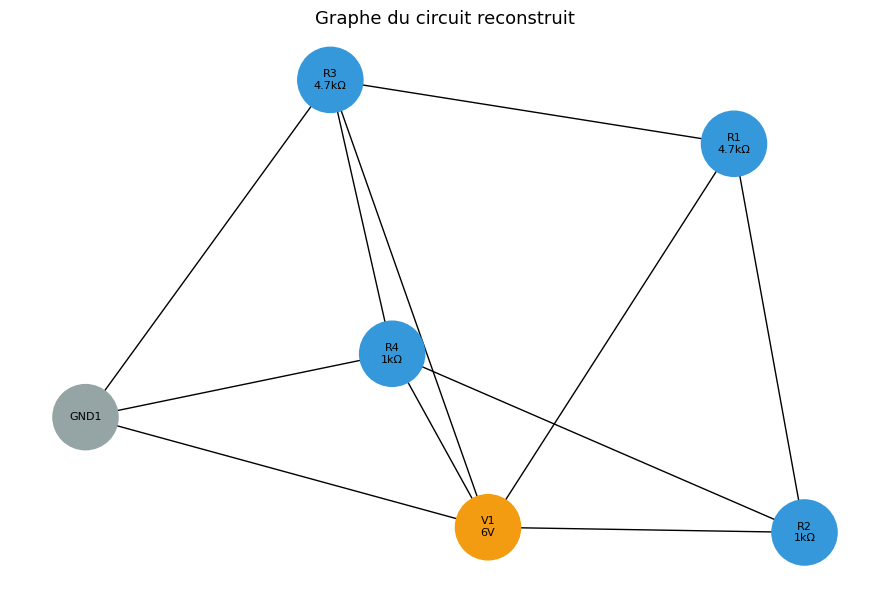

Connexions détaillées, broche par broche :
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — V1.haut
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — V1.haut
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — R2.haut
  R1.haut — V1.haut


In [4]:
graph = result.to_graph(circuit_id=ann_path.stem, source_image=str(image_path))

CLASS_COLORS = {
    'vsource': '#f39c12', 'battery': '#f39c12', 'resistor': '#3498db',
    'capacitor': '#2ecc71', 'polarized_capacitor': '#27ae60',
    'inductor': '#1abc9c', 'ground': '#95a5a6', 'diode': '#e67e22',
    'zener_diode': '#e74c3c', 'led': '#e74c3c', 'opamp': '#9b59b6',
    'npn_transistor': '#8e44ad', 'pnp_transistor': '#8e44ad',
}

G = nx.Graph()
for n in graph.nodes:
    G.add_node(n.id, label=f'{n.id}\n{n.value}' if n.value else n.id, cls=n.cls)
for e in graph.edges:
    G.add_edge(e.source, e.target)

fig, ax = plt.subplots(figsize=(9, 6))
pos = nx.spring_layout(G, seed=42)
colors = [CLASS_COLORS.get(G.nodes[n]['cls'], '#bdc3c7') for n in G.nodes]
nx.draw(G, pos, ax=ax, node_color=colors, node_size=2200, with_labels=False)
nx.draw_networkx_labels(G, pos, {n: G.nodes[n]['label'] for n in G.nodes},
                        font_size=8, ax=ax)
ax.set_title('Graphe du circuit reconstruit', fontsize=13)
plt.tight_layout(); plt.show()

print('Connexions détaillées, broche par broche :')
for e in graph.edges[:12]:
    print(f'  {e.source}.{e.source_terminal} — {e.target}.{e.target_terminal}')

---
## 4. Performances mesurées, étage par étage

Chaque étage a sa propre métrique : un score global unique masquerait l'origine réelle des erreurs.

| Étage | Métrique | Résultat |
|---|---|---|
| Détection (YOLO) | mAP50 | **0,995** |
| Détection | F1 (IoU 0,5) | **1,000** |
| Connectivité | F1 par paires | **0,82** |
| OCR (valeurs) | exact-match | **0,51** |
| LLM sur graphe parfait | précision | **0,99** |

**Lecture de ces chiffres.** Le raisonnement n'est pas le facteur limitant : sur un graphe correct, le LLM répond juste à 99 %. Ce sont l'OCR et la connectivité qui plafonnent la chaîne complète.

**Limite à énoncer.** Entraînement et test proviennent du même générateur : ces scores mesurent la performance sur des schémas synthétiques *de ce style*. La généralisation à des schémas manuscrits ou scannés reste à évaluer.

### Choix de l'OCR : trois moteurs comparés

| Moteur | Exact-match | Décision |
|---|---|---|
| EasyOCR (brut) | 0,11 | insuffisant |
| **EasyOCR + corrections Ω/1** | **0,51** | ✅ retenu |
| PaddleOCR | — | abandonné (incompatibilité modèle/framework) |
| TrOCR-base-printed | 0,42 | rejeté malgré une installation plus simple |

*TrOCR, modèle génératif entraîné sur du texte anglais naturel, s'est révélé moins bon sur des chaînes courtes non linguistiques (« R1 », « 4.7kΩ ») : ses a priori de langue jouent contre lui ici.*

---
## 5. Étape ⑥ : le LLM outillé en action

Pour chaque question : le modèle choisit un outil → nous l'exécutons sur le graphe → il reformule le résultat.

In [6]:
client = QwenClient()
agent = ToolAgent(client, build_tools(graph))

component_ids = [n.id for n in graph.nodes]
print('Composants disponibles :', component_ids)
print()

first_resistor = next((n.id for n in graph.nodes if n.cls == 'resistor'), component_ids[0])
a_diode = next((n.id for n in graph.nodes if n.cls in ('diode', 'zener_diode', 'led')), None)

questions = [
    "Combien de composants y a-t-il dans ce circuit ?",
    "Quels types de composants y a-t-il et en quelle quantité ?",
    "Est-ce un circuit en série, en parallèle, ou mixte ?",
    "Quel est le premier composant du circuit ?",
    f"À quoi sont connectées les broches de {first_resistor} ?",
    "Quels composants sont reliés à la masse ?",
    "Donne-moi la nomenclature du circuit",
    "Y a-t-il des broches non connectées ?",
]
if a_diode:
    questions.insert(5, f"Dans quel sens est orientée la diode {a_diode} ?")

rows = []
for q in questions:
    r = agent.answer(q)
    rows.append({
        'question': q,
        'outil appelé': (r['tool_call'] or {}).get('name'),
        'résultat calculé': str(r['tool_result'])[:60],
        'réponse': r['answer'][:80],
    })

pd.set_option('display.max_colwidth', 60)


Composants disponibles : ['R1', 'R2', 'V1', 'R3', 'R4', 'GND1']



Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [10]:
df=pd.DataFrame(rows)
df

,question,outil appelé,résultat calculé,réponse
0,Combien de composants y a-t-il dans ce circuit ?,count_total_components,6,Il y a 6 composants dans ce circuit.
1,Quels types de composants y a-t-il et en quelle quantité ?,count_components_by_type,"{""résistance"": {""quantité"": 4, ""détail"": [""R1=4.7kΩ"", ""R...","Il y a quatre résistances, chacune à 4.7 kiloohms, avec ..."
2,"Est-ce un circuit en série, en parallèle, ou mixte ?",get_circuit_topology,mixte,Le circuit est mixte.
3,Quel est le premier composant du circuit ?,get_first_component,"R1, R2",Le premier composant du circuit est R1.
4,À quoi sont connectées les broches de R1 ?,get_terminal_connections,"{""bas"": [""R3""], ""haut"": [""R2"", ""V1""]}",Les broches de R1 sont connectées au bas de R3 et à l'ha...
5,Quels composants sont reliés à la masse ?,list_components_connected_to_ground,"[""R3"", ""R4"", ""V1""]","Les composants R3, R4 et V1 sont reliés à la masse."
6,Donne-moi la nomenclature du circuit,get_bill_of_materials,"[""4x résistance (4.7kΩ, 1kΩ, 4.7kΩ, 1kΩ)"", ""1x source de...",Le circuit comporte quatre résistances de 4.7 kΩ et 1 kΩ...
7,Y a-t-il des broches non connectées ?,find_unconnected_terminals,[],Aucun élément ne correspond à cette requête dans ce circ...


In [15]:
for i in range (df.shape[0]):
    print(f" Question : {df["question"]}")

 Question : 0              Combien de composants y a-t-il dans ce circuit ?
1    Quels types de composants y a-t-il et en quelle quantité ?
2          Est-ce un circuit en série, en parallèle, ou mixte ?
3                    Quel est le premier composant du circuit ?
4                    À quoi sont connectées les broches de R1 ?
5                     Quels composants sont reliés à la masse ?
6                          Donne-moi la nomenclature du circuit
7                         Y a-t-il des broches non connectées ?
Name: question, dtype: object
 Question : 0              Combien de composants y a-t-il dans ce circuit ?
1    Quels types de composants y a-t-il et en quelle quantité ?
2          Est-ce un circuit en série, en parallèle, ou mixte ?
3                    Quel est le premier composant du circuit ?
4                    À quoi sont connectées les broches de R1 ?
5                     Quels composants sont reliés à la masse ?
6                          Donne-moi la nomenclatu

---
## 6. Couverture des questions demandées

| # | Question | État |
|---|---|---|
| 1 | Nombre total de composants | ✅ |
| 2 | Série / parallèle / mixte | ✅ |
| 3a | Types et quantités | ✅ |
| 3b/3c | Premier / dernier composant | ✅ |
| 5 | Connexions broche par broche | ✅ |
| 6 | Navigation (voisin direct) | ✅ |
| 7 | Chemin du signal | ✅ |
| 8 | Composants reliés à la masse | ✅ |
| 9 | Polarité et orientation d'une diode | ✅ |
| 10 | Broches non connectées | ✅ |
| 4 | Fonction globale du montage | ⏸️ à venir (classification) |

**Outils supplémentaires ajoutés** : nomenclature (liste d'achat), détection des composants en parallèle, comptage des nœuds électriques.

---

## 7. Suites envisagées

1. **Améliorer l'OCR** (0,51 aujourd'hui) — c'est le principal facteur limitant de la chaîne complète
2. **Détecteur de terminaux dédié** (YOLO-pose) — les labels sont déjà exportés, l'entraînement reste à lancer
3. **Question 4** — classifier la fonction du montage (filtre, redresseur, amplificateur…)
4. **Évaluation hors distribution** — sur des schémas manuscrits ou scannés
5. **Comparaison avec l'approche VLM** — Qwen2.5-VL finetuné, sur le même jeu de test